In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import astropy 
from astropy import units as u 
from astropy.constants import sigma_T, m_p, G, c
import matplotlib.pyplot as plt
import seaborn as sns
from disktab import AGNDisk

In [2]:
M = 1e8 * u.Msun 
MdotEdd = 1e-8 * (M / u.Msun) * (u.Msun / u.yr)
MdotEdd.to(u.kg/u.s)

<Quantity 6.30089066e+22 kg / s>

# Fairbairn Data Cube Access Workflow

This notebook provides methods to extract Fairbairn planet-disk interaction parameters from AGN disk models and access pre-computed torque and damping timescale data.

In [3]:
# Generates Sirko Goodman disk using pagn and converts it to the SpaceHub readable format
import io
from contextlib import redirect_stdout
from pagn import Sirko
import pagn.constants as ct

param_pairs = [(0.1, 1.0),(0.01, 1.0),(0.1, 0.5)]
pagn_dfs = {}
for tup in param_pairs:

    M_msun = 1e8
    alpha_sg = tup[0]
    le       = tup[1]
    eps      = 0.1
    N        = 5000

    # Solve disk (suppress pagn's verbose per-step output; show summary)
    buf = io.StringIO()
    with redirect_stdout(buf):
        sk = Sirko.SirkoAGN(Mbh=M_msun * ct.MSun, alpha=alpha_sg, le=le, eps=eps)
        sk.solve_disk(N=N)
    print(buf.getvalue())

    # ── Unit conversion constants (must match disktab.py spacehub_pretab()) ───────
    AU_m    = 1.495978707e11          # m per AU
    Msun_kg = 1.98847e30              # kg per M☉
    year_s  = 365.25636042 * 24 * 3600
    T_unit  = year_s / (2 * np.pi)   # SpaceHub time unit [s]

    CONV_LENGTH          = 1 / AU_m
    CONV_DENSITY         = AU_m**3 / Msun_kg
    CONV_PRESSURE        = AU_m * T_unit**2 / Msun_kg
    CONV_VELOCITY        = T_unit / AU_m
    CONV_VISCOSITY       = T_unit / AU_m**2
    CONV_SURFACE_DENSITY = AU_m**2 / Msun_kg

    # ── Extract pagn quantities (SI) ─────────────────────────────────────────────
    Rg_si    = ct.G * (M_msun * ct.MSun) / ct.c**2
    R        = sk.R          # [m]
    R_Rg     = R / Rg_si
    Tc       = sk.T          # [K]
    rho      = sk.rho        # [kg/m³]
    cs_si    = sk.cs         # [m/s]
    H_si     = sk.h          # [m]
    Q        = sk.Q          # dimensionless

    P_si     = rho * cs_si**2          # [Pa]   — cs² = P_total/rho in pagn
    visc_si  = alpha_sg * cs_si * H_si # [m²/s]
    Sigma_si = 2 * rho * H_si          # [kg/m²] — slab convention

    # ── Zone labels ───────────────────────────────────────────────────────────────
    isf  = sk.isf  # index where Q < 1 first occurs; -1 if never
    zone = np.array(["Standard"] * len(R))
    if isf > 0:
        zone[isf:] = "Self-Reg"
    #print(f"isf={isf}  (Standard: {(zone=='Standard').sum()} pts, Self-Reg: {(zone=='Self-Reg').sum()} pts)")

    # ── Log gradients, computed zone-by-zone to avoid boundary artifacts ──────────
    def log_gradient(y, x):
        """Compute -d(ln y)/d(ln x) using central differences."""
        return -np.gradient(np.log(y), np.log(x))

    grad_T     = np.zeros_like(R)
    grad_Sigma = np.zeros_like(R)
    grad_P     = np.zeros_like(R)

    if isf > 0 and isf < len(R) - 1:
        for sl in (slice(0, isf), slice(isf, None)):
            grad_T[sl]     = log_gradient(Tc[sl],    R[sl])
            grad_Sigma[sl] = log_gradient(Sigma_si[sl], R[sl])
            grad_P[sl]     = log_gradient(P_si[sl],  R[sl])
    else:
        grad_T     = log_gradient(Tc,       R)
        grad_Sigma = log_gradient(Sigma_si, R)
        grad_P     = log_gradient(P_si,     R)

    # ── Build DataFrame in SpaceHub units ─────────────────────────────────────────
    df_pagn = pd.DataFrame({
        "R":          R        * CONV_LENGTH,
        "R/Rg":       R_Rg,
        "Tc":         Tc,
        "rho":        rho      * CONV_DENSITY,
        "P":          P_si     * CONV_PRESSURE,
        "cs":         cs_si    * CONV_VELOCITY,
        "H":          H_si     * CONV_LENGTH,
        "visc":       visc_si  * CONV_VISCOSITY,
        "Sigma":      Sigma_si * CONV_SURFACE_DENSITY,
        "Q":          Q,
        "grad_T":     grad_T,
        "grad_Sigma": grad_Sigma,
        "grad_P":     grad_P,
        "zone":       zone,
    })

    pagn_dfs[tup] = df_pagn

### Sirko & Goodman 2003 parameters ###
Mbh = 1.000000e+08 MSun
Mdot = 2.596689e+00 MSun/yr
le = 1.0
Rs = 9.570121e-06 pc
Rmin = 2.500000e+00 Rs
Rmax = 1.000000e+07 Rs, 9.570121e+01 pc
alpha = 0.1
b = 0
eps = 0.1
X = 0.7
Opacity = combined

debug = False
xtol = 1e-10
root method = lm
Q<1 at i=2006 (R=1.88e+03 Rs)
Beginning star formation at index 2006
Mdisk = 195428658.3172341 Msun
Mdisk/Mbh = 1.9542865831723408

### Sirko & Goodman 2003 parameters ###
Mbh = 1.000000e+08 MSun
Mdot = 2.596689e+00 MSun/yr
le = 1.0
Rs = 9.570121e-06 pc
Rmin = 2.500000e+00 Rs
Rmax = 1.000000e+07 Rs, 9.570121e+01 pc
alpha = 0.01
b = 0
eps = 0.1
X = 0.7
Opacity = combined

debug = False
xtol = 1e-10
root method = lm
Q<1 at i=1751 (R=9.07e+02 Rs)
Beginning star formation at index 1751
Mdisk = 422375337.90807015 Msun
Mdisk/Mbh = 4.223753379080701

### Sirko & Goodman 2003 parameters ###
Mbh = 1.000000e+08 MSun
Mdot = 1.298344e+00 MSun/yr
le = 0.5
Rs = 9.570121e-06 pc
Rmin = 2.500000e+00 Rs
Rmax = 1.000000e+07 

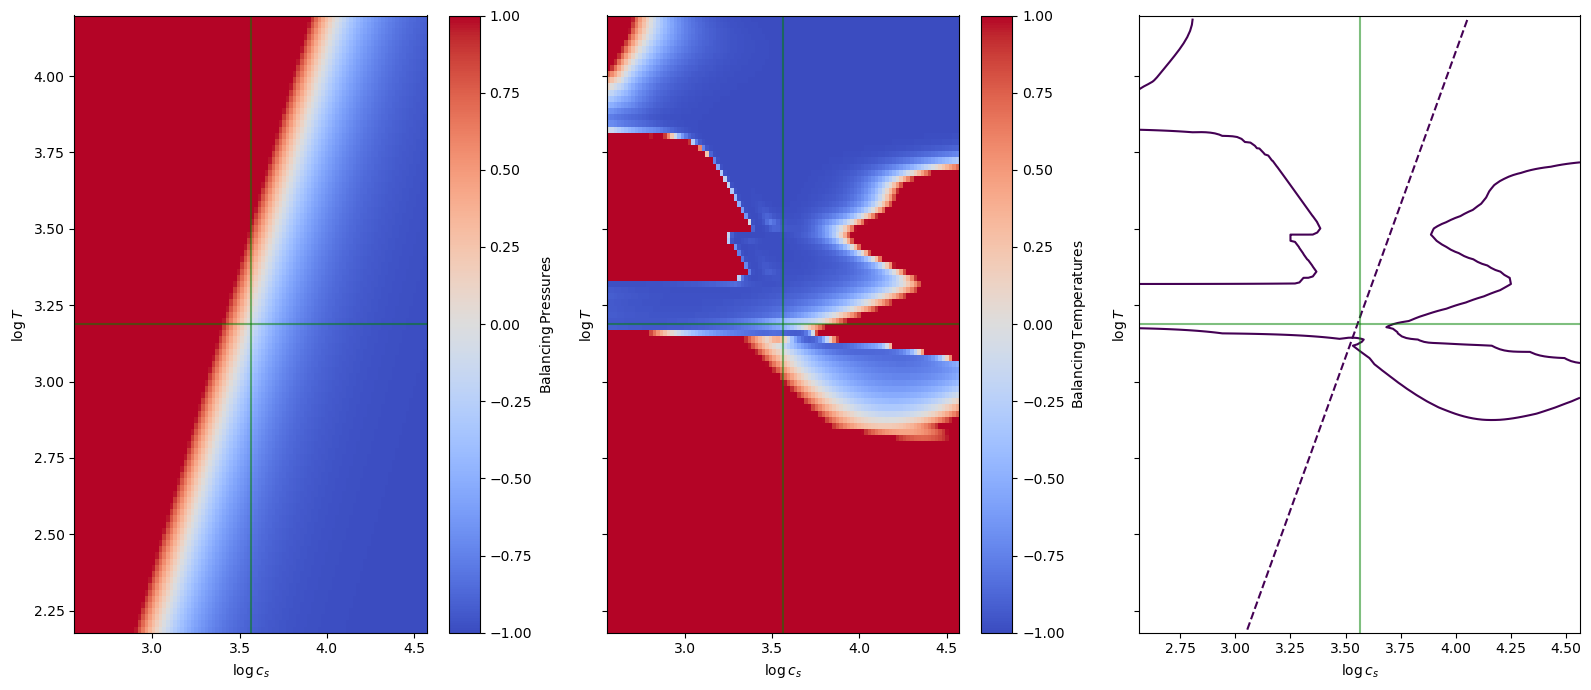

### Sirko & Goodman 2003 parameters ###
Mbh = 1.000000e+00 MSun
Mdot = 2.596689e-12 MSun/yr
le = 0.0001
Rs = 9.570121e-14 pc
Rmin = 2.500000e+00 Rs
Rmax = 1.000000e+07 Rs, 9.570121e-07 pc
alpha = 0.01
b = 0
eps = 0.1
X = 0.7
Opacity = combined

debug = False
xtol = 1e-10
root method = lm
No no star formation regime solution found at index 3606 
Zero residuals: [-0.04324032 -0.07723618]
Last solution: [3.56349529 3.18795926]
Showing root finding solutions for no star formation regime
### Plotting no star formation regime solutions ###
i = 3606 
R = 1.844893e+05 Rs = 1.765585e-08 pc
guess = (log cs, log T) = (3.563495291546324 , 3.187959262762073)
zoom guess = True
###
Mdisk = 8.171382074725058e-11 Msun
Mdisk/Mbh = 8.171382074725058e-11



/tmp/ipykernel_15391/2375844991.py:51: RuntimeWarning: divide by zero encountered in log
  return -np.gradient(np.log(y), np.log(x))
/usr/lib64/python3.13/site-packages/numpy/lib/_function_base_impl.py:1298: RuntimeWarning: invalid value encountered in multiply
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]
/usr/lib64/python3.13/site-packages/numpy/lib/_function_base_impl.py:1298: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]
/usr/lib64/python3.13/site-packages/numpy/lib/_function_base_impl.py:1314: RuntimeWarning: invalid value encountered in scalar subtract
  out[tuple(slice1)] = (f[tuple(slice2)] - f[tuple(slice3)]) / dx_n


,R,R/Rg,Tc,rho,P,cs,H,visc,Sigma,Q,grad_T,grad_Sigma,grad_P,zone
0,1.186211e-07,12.017216,7.228633e+06,807098.248477,5.598625e+07,8.328705,3.402626e-10,2.833947e-11,0.000549,1.181431e+14,0.432617,0.164171,1.878706,Standard
1,1.189614e-07,12.051698,7.219678e+06,803752.843963,5.568568e+07,8.323587,3.415182e-10,2.842656e-11,0.000549,1.176194e+14,0.433090,0.165513,1.880288,Standard
2,1.193028e-07,12.086279,7.210715e+06,800416.248138,5.538623e+07,8.318460,3.427779e-10,2.851385e-11,0.000549,1.170988e+14,0.434031,0.168189,1.883441,Standard
3,1.196451e-07,12.120959,7.201743e+06,797088.493945,5.508789e+07,8.313326,3.440419e-10,2.860132e-11,0.000548,1.165813e+14,0.434964,0.170850,1.886575,Standard
4,1.199884e-07,12.155739,7.192764e+06,793769.613420,5.479067e+07,8.308183,3.453100e-10,2.868898e-11,0.000548,1.160667e+14,0.435890,0.173495,1.889689,Standard


In [4]:
M_msun = 1
alpha_sg = 0.01
le       = 1e-4
eps      = 0.1
N        = 5000

# Solve disk (suppress pagn's verbose per-step output; show summary)
buf = io.StringIO()
with redirect_stdout(buf):
    sk = Sirko.SirkoAGN(Mbh=M_msun * ct.MSun, alpha=alpha_sg, le=le, eps=eps)
    sk.solve_disk(N=N)
print(buf.getvalue())

# ── Unit conversion constants (must match disktab.py spacehub_pretab()) ───────
AU_m    = 1.495978707e11          # m per AU
Msun_kg = 1.98847e30              # kg per M☉
year_s  = 365.25636042 * 24 * 3600
T_unit  = year_s / (2 * np.pi)   # SpaceHub time unit [s]

CONV_LENGTH          = 1 / AU_m
CONV_DENSITY         = AU_m**3 / Msun_kg
CONV_PRESSURE        = AU_m * T_unit**2 / Msun_kg
CONV_VELOCITY        = T_unit / AU_m
CONV_VISCOSITY       = T_unit / AU_m**2
CONV_SURFACE_DENSITY = AU_m**2 / Msun_kg

# ── Extract pagn quantities (SI) ─────────────────────────────────────────────
Rg_si    = ct.G * (M_msun * ct.MSun) / ct.c**2
R        = sk.R          # [m]
R_Rg     = R / Rg_si
Tc       = sk.T          # [K]
rho      = sk.rho        # [kg/m³]
cs_si    = sk.cs         # [m/s]
H_si     = sk.h          # [m]
Q        = sk.Q          # dimensionless

P_si     = rho * cs_si**2          # [Pa]   — cs² = P_total/rho in pagn
visc_si  = alpha_sg * cs_si * H_si # [m²/s]
Sigma_si = 2 * rho * H_si          # [kg/m²] — slab convention

# ── Zone labels ───────────────────────────────────────────────────────────────
isf  = sk.isf  # index where Q < 1 first occurs; -1 if never
zone = np.array(["Standard"] * len(R))
if isf > 0:
    zone[isf:] = "Self-Reg"
#print(f"isf={isf}  (Standard: {(zone=='Standard').sum()} pts, Self-Reg: {(zone=='Self-Reg').sum()} pts)")

# ── Log gradients, computed zone-by-zone to avoid boundary artifacts ──────────
def log_gradient(y, x):
    """Compute -d(ln y)/d(ln x) using central differences."""
    return -np.gradient(np.log(y), np.log(x))

grad_T     = np.zeros_like(R)
grad_Sigma = np.zeros_like(R)
grad_P     = np.zeros_like(R)

if isf > 0 and isf < len(R) - 1:
    for sl in (slice(0, isf), slice(isf, None)):
        grad_T[sl]     = log_gradient(Tc[sl],    R[sl])
        grad_Sigma[sl] = log_gradient(Sigma_si[sl], R[sl])
        grad_P[sl]     = log_gradient(P_si[sl],  R[sl])
else:
    grad_T     = log_gradient(Tc,       R)
    grad_Sigma = log_gradient(Sigma_si, R)
    grad_P     = log_gradient(P_si,     R)

# ── Build DataFrame in SpaceHub units ─────────────────────────────────────────
df_ppd = pd.DataFrame({
    "R":          R        * CONV_LENGTH,
    "R/Rg":       R_Rg,
    "Tc":         Tc,
    "rho":        rho      * CONV_DENSITY,
    "P":          P_si     * CONV_PRESSURE,
    "cs":         cs_si    * CONV_VELOCITY,
    "H":          H_si     * CONV_LENGTH,
    "visc":       visc_si  * CONV_VISCOSITY,
    "Sigma":      Sigma_si * CONV_SURFACE_DENSITY,
    "Q":          Q,
    "grad_T":     grad_T,
    "grad_Sigma": grad_Sigma,
    "grad_P":     grad_P,
    "zone":       zone,
})

df_ppd.head(5)

In [5]:
# Create disk object
disk = AGNDisk()

# Set required parameters
disk.M = 1e8 * u.Msun          # Central black hole mass
disk.alpha = 0.1               # Shakura-Sunyaev viscosity parameter

# Accretion rate as a fraction of the Eddington limit
MdotEddFrac = 0.5              # Fraction of Eddington accretion rate
epsilon = 0.1                   # Radiative efficiency (0.1 for Schwarzschild BH)

kappa = sigma_T / m_p           # Electron scattering opacity
L_Edd = 4 * np.pi * G * disk.M * c / kappa   # Eddington luminosity
Mdot_Edd = (L_Edd / (epsilon * c**2)).to(u.kg / u.s)  # Eddington accretion rate
#disk.Mdot = MdotEddFrac * Mdot_Edd
disk.Mdot = 1e23 * u.kg / u.s
# Generate the disk profile
# rvals can be passed as dimensionless (multiples of Rg) or with units
# If omitted, uses default: 200 log-spaced points from 10 to 10^7 Rg
#df = disk.spacehub_pretab(rvals=np.linspace(10, 10**7, 500))
df = disk.spacehub_pretab(rvals=np.logspace(1, 9, 500))
df.tail(10)

/home/mars/Computing/AGN/SpaceHub-Tinkering/disktab/disktab.py:1105: UserWarning: Zone boundary smoothing skipped: gap [62, 262) with slope window w=100 exceeds data range [0, 500). Reduce n_gap or w.
  self.generate(rvals=rvals)


,R,R/Rg,Tc,rho,P,cs,H,visc,Sigma,Q,grad_T,grad_Sigma,grad_P,zone
490,7.080375e+08,7.173175e+08,3.026788,4.483718e-20,3.997735e-20,0.944252,1.778987e+09,1.679812e+08,1.595295e-10,1.0,0.749983,1.499985,2.999970,Self-Reg
491,7.346632e+08,7.442922e+08,2.944139,4.013674e-20,3.578642e-20,0.944252,1.880274e+09,1.775453e+08,1.509361e-10,1.0,0.749983,1.499985,2.999970,Self-Reg
492,7.622903e+08,7.722814e+08,2.863746,3.592906e-20,3.203484e-20,0.944253,1.987328e+09,1.876540e+08,1.428057e-10,1.0,0.749983,1.499985,2.999971,Self-Reg
493,7.909562e+08,8.013230e+08,2.785548,3.216249e-20,2.867654e-20,0.944253,2.100477e+09,1.983382e+08,1.351131e-10,1.0,0.749984,1.499986,2.999971,Self-Reg
494,8.207001e+08,8.314568e+08,2.709486,2.879079e-20,2.567031e-20,0.944254,2.220067e+09,2.096307e+08,1.278350e-10,1.0,0.749984,1.499986,2.999972,Self-Reg
495,8.515626e+08,8.627237e+08,2.635501,2.577255e-20,2.297922e-20,0.944254,2.346467e+09,2.215662e+08,1.209489e-10,1.0,0.749985,1.499986,2.999972,Self-Reg
496,8.835856e+08,8.951665e+08,2.563535,2.307072e-20,2.057025e-20,0.944255,2.480064e+09,2.341812e+08,1.144337e-10,1.0,0.749985,1.499986,2.999973,Self-Reg
497,9.168128e+08,9.288292e+08,2.493535,2.065213e-20,1.841382e-20,0.944255,2.621266e+09,2.475145e+08,1.082695e-10,1.0,0.749985,1.499987,2.999973,Self-Reg
498,9.512896e+08,9.637579e+08,2.425446,1.848710e-20,1.648345e-20,0.944256,2.770508e+09,2.616068e+08,1.024373e-10,1.0,0.749986,1.499987,2.999974,Self-Reg
499,9.870629e+08,1.000000e+09,2.359217,1.654903e-20,1.475544e-20,0.944256,2.928247e+09,2.765016e+08,9.691930e-11,1.0,0.749986,1.499987,2.999974,Self-Reg


[None]

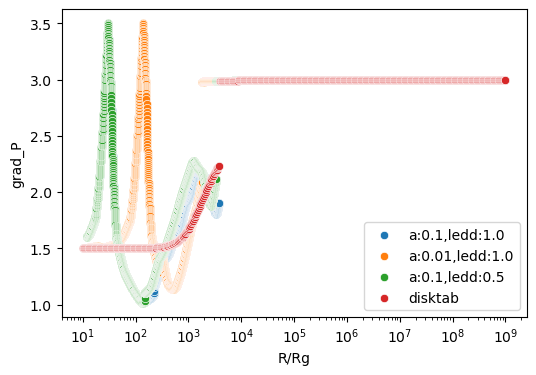

In [6]:
fig, ax = plt.subplots(figsize=(6,4))
for tup in pagn_dfs.keys():
    sns.scatterplot(data=pagn_dfs[tup], x="R/Rg", y="grad_P", ax=ax, label=f"a:{tup[0]},ledd:{tup[1]}")
    

sns.scatterplot(data=df, x="R/Rg", y="grad_P", ax=ax, label=f"disktab")

ax.set(xscale="log")

## 1. Disk Model Setup

Generate a modified Shakura-Sunyaev disk profile with Sirko-Goodman Q=1 self-regulation.

In [7]:
from scipy.interpolate import interp1d

def powerlaw_p(df, R):
    """Get Fairbairn powerlaw exponent p from spacehub-formatted disk file.
    
    Parameters:
        df: DataFrame from AGNDisk.spacehub_pretab()
        R: Radial distance in gravitational radii (dimensionless)
    
    Returns:
        p: Surface density exponent, where Σ(r) ∝ r^(-p)
    """
    # Create interpolator for grad_Sigma vs R/Rg
    interp = interp1d(df['R/Rg'], df['grad_Sigma'], kind='linear', 
                      bounds_error=False, fill_value='extrapolate')
    return float(interp(R))

def powerlaw_q(df, R):
    """Get Fairbairn temperature exponent q from spacehub-formatted disk file.
    
    Parameters:
        df: DataFrame from AGNDisk.spacehub_pretab()
        R: Radial distance in gravitational radii (dimensionless)
    
    Returns:
        q: Temperature exponent, where T(r) ∝ r^(-q)
    """
    # Create interpolator for grad_T vs R/Rg
    interp = interp1d(df['R/Rg'], df['grad_T'], kind='linear',
                      bounds_error=False, fill_value='extrapolate')
    return float(interp(R))

def fairbairn_h(df, R):
    """Calculate aspect ratio h as defined in Fairbairn from spacehub-formatted disk file.
    
    Parameters:
        df: DataFrame from AGNDisk.spacehub_pretab()
        R: Radial distance in gravitational radii (dimensionless)
    
    Returns:
        h: Disk aspect ratio h = H/r at the specified radius
    """
    # Interpolate H and R separately, then compute h = H/R
    H_interp = interp1d(df['R/Rg'], df['H'], kind='linear',
                        bounds_error=False, fill_value='extrapolate')
    R_interp = interp1d(df['R/Rg'], df['R'], kind='linear',
                        bounds_error=False, fill_value='extrapolate')
    
    H_val = float(H_interp(R))
    R_val = float(R_interp(R))
    
    return H_val / R_val

## 2. Fairbairn Parameter Extraction

Methods to calculate p, q, h parameters from disk model at a given radius for accessing Fairbairn torque data.

In [8]:
from scipy.interpolate import RegularGridInterpolator
import os

# Path to Fairbairn eccentric data
_data_dir = os.path.join(os.path.abspath(".."), 'FairbairnData', 'eccentric')

# Read parameter grids
with open(os.path.join(_data_dir, 'parameters.out'), 'r') as f:
    q_grid = np.array(f.readline().split(), dtype=float)
    p_grid = np.array(f.readline().split(), dtype=float)
    h_grid = np.array(f.readline().split(), dtype=float)
    e_grid = np.array(f.readline().split(), dtype=float)

_shape = (len(q_grid), len(p_grid), len(h_grid), len(e_grid))

# Load and reshape datacubes
tau_a_inv_data = np.loadtxt(os.path.join(_data_dir, 'tau_a_inv.out')).reshape(_shape)
t_net_data = np.loadtxt(os.path.join(_data_dir, 't_net.out')).reshape(_shape)

# Build 4D interpolators over (q, p, h, e)
_tau_a_inv_interp = RegularGridInterpolator(
    (q_grid, p_grid, h_grid, e_grid), tau_a_inv_data, bounds_error=False, fill_value=None
)
_t_net_interp = RegularGridInterpolator(
    (q_grid, p_grid, h_grid, e_grid), t_net_data, bounds_error=False, fill_value=None
)

## 3. Fairbairn Data Cube Loading

Load pre-computed Fairbairn & Rafikov (2024) planet-disk interaction data organized as 4D interpolators over (q, p, h, e).

In [9]:
def get_tau_a_inv(p, q, h, e):
    """Return tau_a^{-1} (semi-major axis damping rate) interpolated from the Fairbairn datacube.

    Dimensionless, normalized by tau_0^{-1} = F_{J,0} / (M_p * Omega_p * a^2)
    where F_{J,0} = Sigma_p * a^4 * Omega_p^2 * h_p^{-3} * (M_p / M_*)^2.
    """
    return float(_tau_a_inv_interp((q, p, h, e)))

## 4. Interpolation Functions

Query Fairbairn data cubes for torques and damping timescales at arbitrary (p, q, h, e) values.

In [10]:
def get_T_net(p, q, h, e):
    """Return T_net (net torque) interpolated from the Fairbairn datacube.

    Dimensionless, normalized by F_{J,0} = Sigma_p * a^4 * Omega_p^2 * h_p^{-3} * (M_p / M_*)^2.
    """
    return float(_t_net_interp((q, p, h, e)))

def t_net_fitted(p, q, h, a, df):
    #Sigma_p = Sigma(a)
    #Omega_p = sqrt(G*M/(a**3))
    #h_p = H(a)/a
    #MRatio2 = ? (M_p/Mstar)**2
    FJ0 = 0 #replace
    return FJ0 * (1.413 + 1.109*q + 1.237*p - 0.017*q*p)*hp**(1.025)

# Tests

## Test 1: Extract Parameters Across Disk Regions

Test parameter extraction at radii spanning radiation-dominated, gas pressure dominated, and Q=1 self-regulated zones.

In [11]:
# Define test radii for each disk region
test_radii = {
    'Radiation-dominated': [10, 30, 100],
    'Gas-dominated': [1e3, 5e3, 1e4],
    'Q=1 Self-regulated': [1e5, 5e5, 1e6]
}

# Fairbairn grid boundaries - Yes it goes q,p,h which is counter-intuitive but this is how their example notebook does it
p_bounds = (0.0, 1.5)
q_bounds = (0.0, 0.75)
h_bounds = (0.06, 0.10)

# Extract parameters at each radius
results = []
for region, radii in test_radii.items():
    for R in radii:
        p = powerlaw_p(df, R)
        q = powerlaw_q(df, R)
        h = fairbairn_h(df, R)
        
        # Determine zone from dataframe
        zone_idx = np.argmin(np.abs(df['R/Rg'].values - R))
        zone = df.iloc[zone_idx]['zone']
        
        # Check if within Fairbairn bounds
        p_ok = p_bounds[0] <= p <= p_bounds[1]
        q_ok = q_bounds[0] <= q <= q_bounds[1]
        h_ok = h_bounds[0] <= h <= h_bounds[1]
        
        results.append({
            'Region': region,
            'R/Rg': R,
            'Zone': zone,
            'p': p,
            'q': q,
            'h': h,
            'p_OK': '✓' if p_ok else '✗',
            'q_OK': '✓' if q_ok else '✗',
            'h_OK': '✓' if h_ok else '✗'
        })

# Display results
results_df = pd.DataFrame(results)
print("\n=== Parameter Extraction Test Results ===\n")
print(f"Fairbairn Grid Bounds:")
print(f"  p ∈ [{p_bounds[0]}, {p_bounds[1]}]")
print(f"  q ∈ [{q_bounds[0]}, {q_bounds[1]}]")
print(f"  h ∈ [{h_bounds[0]}, {h_bounds[1]}]")
print(f"\n{results_df.to_string(index=False)}")

# Flag any out-of-bounds parameters
out_of_bounds = results_df[(results_df['p_OK'] == '✗') | 
                           (results_df['q_OK'] == '✗') | 
                           (results_df['h_OK'] == '✗')]
if len(out_of_bounds) > 0:
    print(f"\n⚠ Warning: {len(out_of_bounds)} radii have parameters outside Fairbairn coverage")
else:
    print("\n✓ All parameters within Fairbairn grid bounds")


=== Parameter Extraction Test Results ===

Fairbairn Grid Bounds:
  p ∈ [0.0, 1.5]
  q ∈ [0.0, 0.75]
  h ∈ [0.06, 0.1]

             Region      R/Rg     Zone         p        q        h p_OK q_OK h_OK
Radiation-dominated      10.0 Standard  0.145208 0.374997 0.253635    ✓    ✓    ✗
Radiation-dominated      30.0 Standard -1.095794 0.375023 0.206876    ✗    ✓    ✗
Radiation-dominated     100.0 Standard -1.336555 0.375340 0.084766    ✗    ✓    ✓
      Gas-dominated    1000.0 Standard -1.112787 0.460715 0.011197    ✗    ✓    ✗
      Gas-dominated    5000.0 Self-Reg  1.494024 0.655648 0.006557    ✓    ✓    ✗
      Gas-dominated   10000.0 Self-Reg  1.495818 0.698272 0.009305    ✓    ✓    ✗
 Q=1 Self-regulated  100000.0 Self-Reg  1.498700 0.741453 0.029594    ✓    ✓    ✗
 Q=1 Self-regulated  500000.0 Self-Reg  1.499421 0.747391 0.066264    ✓    ✓    ✓
 Q=1 Self-regulated 1000000.0 Self-Reg  1.499591 0.748421 0.093744    ✓    ✓    ✓

⚠ Warning: 7 radii have parameters outside Fairbairn cover

(10, 1000000)

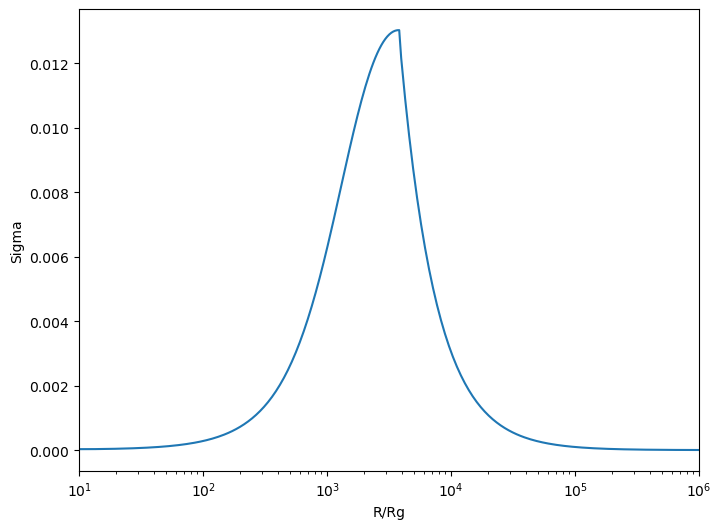

In [12]:
fig, ax = plt.subplots(figsize=(8,6))
sns.lineplot(data=df, x="R/Rg", y="Sigma")
ax.set_xscale("log")
ax.set_xlim(10,10**6)

In [13]:
list(pagn_dfs.keys())

[(0.1, 1.0), (0.01, 1.0), (0.1, 0.5)]

## Test 2: Plot Parameter Profiles

Visualize p(R), q(R), h(R) across the full disk with region identification and Fairbairn grid boundaries.

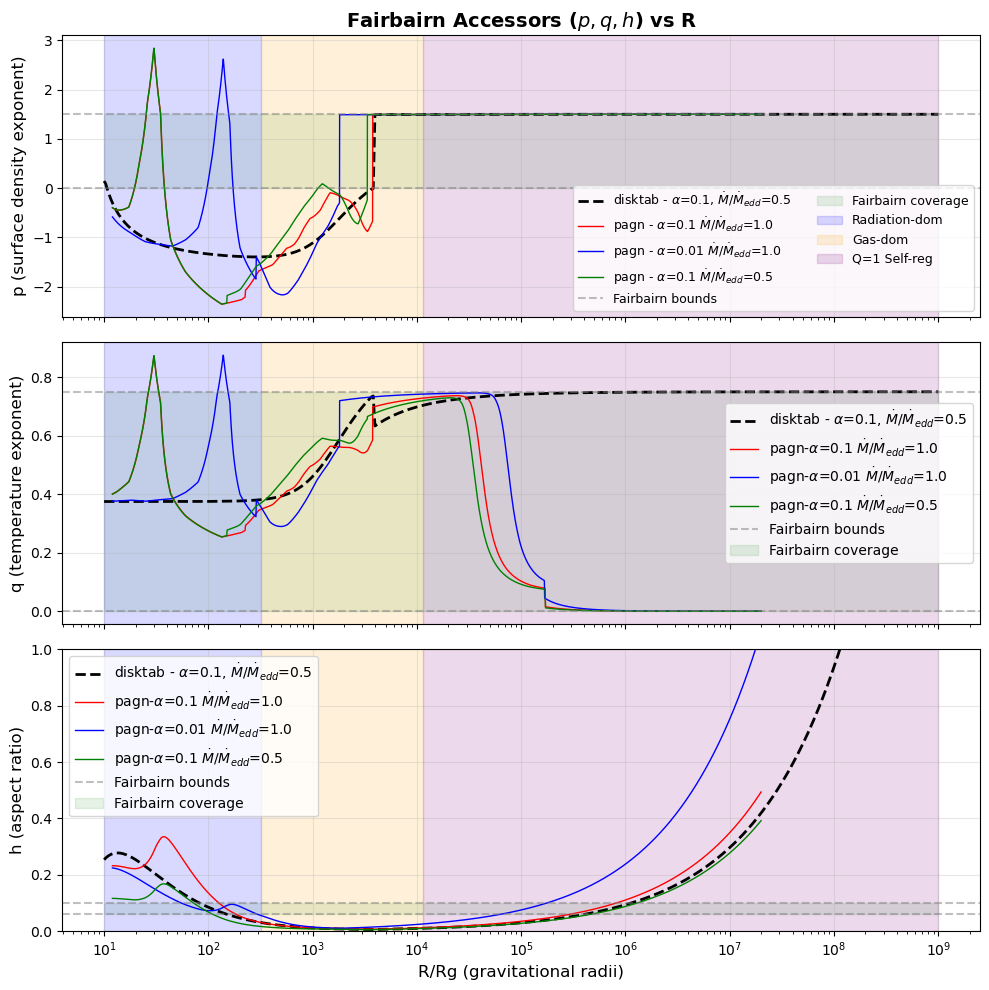


=== Parameter Coverage Summary ===
p within Fairbairn bounds: 340/500 (68.0%)
q within Fairbairn bounds: 500/500 (100.0%)
h within Fairbairn bounds: 45/500 (9.0%)


In [14]:
# Find zone transition radius
zone_transition_idx = np.where(df['zone'] == 'SelfReg')[0]
if len(zone_transition_idx) > 0:
    zone_transition_R = df.iloc[zone_transition_idx[0]]['R/Rg']
else:
    zone_transition_R = None

# Create figure with 3 panels
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)


# Plot p(R)
ax = axes[0]
ax.plot(df['R/Rg'], df['grad_Sigma'], 'black', linestyle="--", linewidth=2, label=r'disktab - $\alpha$=0.1, $\dot{{M}}/\dot{{M}}_{{edd}}$=0.5')
#ax.plot(df_ppd['R/Rg'], df_ppd['grad_Sigma'], 'magenta', linestyle="-.", linewidth=2, label=r'pagn - PPD')
colord = {list(pagn_dfs.keys())[0]: "red", list(pagn_dfs.keys())[1]: "blue", list(pagn_dfs.keys())[2]: "green"}
for tup, pdf in pagn_dfs.items():
    ax.plot(pdf['R/Rg'], pdf['grad_Sigma'], linewidth=1, label=rf'pagn - $\alpha$={tup[0]} $\dot{{M}}/\dot{{M}}_{{edd}}$={tup[1]}', color=colord[tup])
ax.axhline(p_bounds[0], color='gray', linestyle='--', alpha=0.5, label='Fairbairn bounds')
ax.axhline(p_bounds[1], color='gray', linestyle='--', alpha=0.5)
ax.fill_between([df['R/Rg'].min(), df['R/Rg'].max()], p_bounds[0], p_bounds[1], 
                 color='green', alpha=0.1, label='Fairbairn coverage')
if zone_transition_R:
    ax.axvline(zone_transition_R, color='red', linestyle=':', linewidth=2, label='Zone transition')
ax.set_ylabel('p (surface density exponent)', fontsize=12)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=10)
ax.set_title(r'Fairbairn Accessors ($p,q,h$) vs R', fontsize=14, fontweight='bold')

# Plot q(R)
ax = axes[1]
ax.plot(df['R/Rg'], df['grad_T'], 'black', linestyle="--", linewidth=2, label=r'disktab - $\alpha$=0.1, $\dot{{M}}/\dot{{M}}_{{edd}}$=0.5')
#ax.plot(df_ppd['R/Rg'], df_ppd['grad_T'], 'magenta', linestyle="-.", linewidth=2, label=r'pagn - PPD')
for tup, pdf in pagn_dfs.items():
    ax.plot(pdf['R/Rg'], pdf['grad_T'], linewidth=1, label=rf'pagn-$\alpha$={tup[0]} $\dot{{M}}/\dot{{M}}_{{edd}}$={tup[1]}', color=colord[tup])
ax.axhline(q_bounds[0], color='gray', linestyle='--', alpha=0.5, label='Fairbairn bounds')
ax.axhline(q_bounds[1], color='gray', linestyle='--', alpha=0.5)
ax.fill_between([df['R/Rg'].min(), df['R/Rg'].max()], q_bounds[0], q_bounds[1], 
                 color='green', alpha=0.1, label='Fairbairn coverage')
if zone_transition_R:
    ax.axvline(zone_transition_R, color='red', linestyle=':', linewidth=2, label='Zone transition')
ax.set_ylabel('q (temperature exponent)', fontsize=12)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=10)

# Plot h(R)
ax = axes[2]
h_profile = df['H'] / df['R']
h_profile_ppd = df_ppd['H'] / df_ppd['R']

ax.plot(df['R/Rg'], h_profile, 'black', linewidth=2, linestyle="--", label=r'disktab - $\alpha$=0.1, $\dot{{M}}/\dot{{M}}_{{edd}}$=0.5')
#ax.plot(df_ppd['R/Rg'], h_profile_ppd, 'magenta', linestyle="-.", linewidth=2, label=r'pagn - PPD')
for tup, pdf in pagn_dfs.items():
    h_profile_pagn = pdf['H'] / pdf['R']
    ax.plot(pdf['R/Rg'], h_profile_pagn, linewidth=1, label=rf'pagn-$\alpha$={tup[0]} $\dot{{M}}/\dot{{M}}_{{edd}}$={tup[1]}', color=colord[tup])
ax.axhline(h_bounds[0], color='gray', linestyle='--', alpha=0.5, label='Fairbairn bounds')
ax.axhline(h_bounds[1], color='gray', linestyle='--', alpha=0.5)
ax.fill_between([df['R/Rg'].min(), df['R/Rg'].max()], h_bounds[0], h_bounds[1], 
                 color='green', alpha=0.1, label='Fairbairn coverage')
if zone_transition_R:
    ax.axvline(zone_transition_R, color='red', linestyle=':', linewidth=2, label='Zone transition')
ax.set_ylabel('h (aspect ratio)', fontsize=12)
ax.set_xlabel('R/Rg (gravitational radii)', fontsize=12)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=10)
axes[2].set_ylim(0,1)
# Add region shading
region_shading_alpha = 0.15
for ax in axes:
    ax.axvspan(10, 10**(2.5), alpha=region_shading_alpha, color='blue', label='Radiation-dom' if ax == axes[0] else '')
    ax.axvspan(10**(2.5), 1.15e4, alpha=region_shading_alpha, color='orange', label='Gas-dom' if ax == axes[0] else '')
    ax.axvspan(1.15e4, 1e9, alpha=region_shading_alpha, color='purple', label='Q=1 Self-reg' if ax == axes[0] else '')

# Update legend for first panel to include regions
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, loc='lower right', fontsize=9, ncol=2)

plt.tight_layout()
plt.show()

# Summary
print("\n=== Parameter Coverage Summary ===")
p_in_range = np.sum((df['grad_Sigma'] >= p_bounds[0]) & (df['grad_Sigma'] <= p_bounds[1]))
q_in_range = np.sum((df['grad_T'] >= q_bounds[0]) & (df['grad_T'] <= q_bounds[1]))
h_in_range = np.sum((h_profile >= h_bounds[0]) & (h_profile <= h_bounds[1]))
total_pts = len(df)

print(f"p within Fairbairn bounds: {p_in_range}/{total_pts} ({100*p_in_range/total_pts:.1f}%)")
print(f"q within Fairbairn bounds: {q_in_range}/{total_pts} ({100*q_in_range/total_pts:.1f}%)")
print(f"h within Fairbairn bounds: {h_in_range}/{total_pts} ({100*h_in_range/total_pts:.1f}%)")

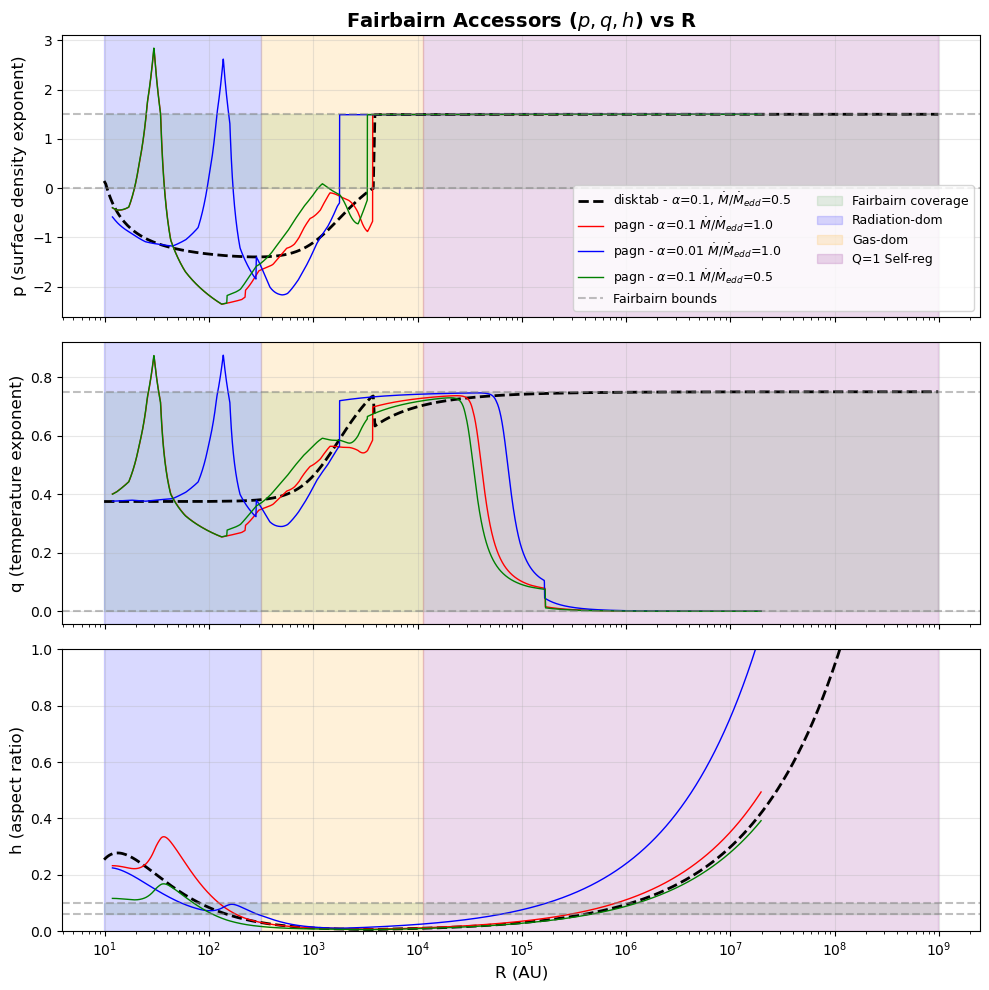

In [15]:
# ── Convert gravitational radii → AU for M = 1e8 Msun ────────────────────────
Rg_AU = ct.G * (1e8 * ct.MSun) / ct.c**2 / ct.au   # Rg in AU

zone_rad_lo_AU  = 10        * Rg_AU   # inner edge (plot start)
zone_rad_hi_AU  = 10**2.5   * Rg_AU   # radiation-dom / gas-dom boundary
zone_gas_hi_AU  = 1.15e4    * Rg_AU   # gas-dom / self-reg boundary
zone_self_hi_AU = 1e9       * Rg_AU   # outer edge

# Zone transition radius in AU
zone_transition_idx_au = np.where(df['zone'] == 'SelfReg')[0]
zone_transition_R_AU = df.iloc[zone_transition_idx_au[0]]['R'] if len(zone_transition_idx_au) > 0 else None

# Create figure with 3 panels
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Plot p(R)
ax = axes[0]
ax.plot(df['R'], df['grad_Sigma'], 'black', linestyle="--", linewidth=2, label=r'disktab - $\alpha$=0.1, $\dot{{M}}/\dot{{M}}_{{edd}}$=0.5')
#ax.plot(df_ppd['R'], df_ppd['grad_Sigma'], 'magenta', linestyle="-.", linewidth=2, label=r'pagn - PPD')
for tup, pdf in pagn_dfs.items():
    ax.plot(pdf['R'], pdf['grad_Sigma'], linewidth=1, label=rf'pagn - $\alpha$={tup[0]} $\dot{{M}}/\dot{{M}}_{{edd}}$={tup[1]}', color=colord[tup])
ax.axhline(p_bounds[0], color='gray', linestyle='--', alpha=0.5, label='Fairbairn bounds')
ax.axhline(p_bounds[1], color='gray', linestyle='--', alpha=0.5)
ax.fill_between([df['R'].min(), df['R'].max()], p_bounds[0], p_bounds[1],
                 color='green', alpha=0.1, label='Fairbairn coverage')
if zone_transition_R_AU:
    ax.axvline(zone_transition_R_AU, color='red', linestyle=':', linewidth=2, label='Zone transition')
ax.set_ylabel('p (surface density exponent)', fontsize=12)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.set_title(r'Fairbairn Accessors ($p,q,h$) vs R', fontsize=14, fontweight='bold')

# Plot q(R)
ax = axes[1]
ax.plot(df['R'], df['grad_T'], 'black', linestyle="--", linewidth=2)
#ax.plot(df_ppd['R'], df_ppd['grad_T'], 'magenta', linestyle="-.", linewidth=2)
for tup, pdf in pagn_dfs.items():
    ax.plot(pdf['R'], pdf['grad_T'], linewidth=1, color=colord[tup])
ax.axhline(q_bounds[0], color='gray', linestyle='--', alpha=0.5)
ax.axhline(q_bounds[1], color='gray', linestyle='--', alpha=0.5)
ax.fill_between([df['R'].min(), df['R'].max()], q_bounds[0], q_bounds[1],
                 color='green', alpha=0.1)
if zone_transition_R_AU:
    ax.axvline(zone_transition_R_AU, color='red', linestyle=':', linewidth=2)
ax.set_ylabel('q (temperature exponent)', fontsize=12)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# Plot h(R)
ax = axes[2]
h_profile_au = df['H'] / df['R']
h_profile_ppd_au = df_ppd['H'] / df_ppd['R']
ax.plot(df['R'], h_profile_au, 'black', linewidth=2, linestyle="--")
#ax.plot(df_ppd['R'], h_profile_ppd_au, 'magenta', linestyle="-.", linewidth=2)
for tup, pdf in pagn_dfs.items():
    ax.plot(pdf['R'], pdf['H'] / pdf['R'], linewidth=1, color=colord[tup])
ax.axhline(h_bounds[0], color='gray', linestyle='--', alpha=0.5)
ax.axhline(h_bounds[1], color='gray', linestyle='--', alpha=0.5)
ax.fill_between([df['R'].min(), df['R'].max()], h_bounds[0], h_bounds[1],
                 color='green', alpha=0.1)
if zone_transition_R_AU:
    ax.axvline(zone_transition_R_AU, color='red', linestyle=':', linewidth=2)
ax.set_ylabel('h (aspect ratio)', fontsize=12)
ax.set_xlabel('R (AU)', fontsize=12)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
axes[2].set_ylim(0, 1)

# Add region shading (all panels, legend labels only on first)
region_shading_alpha = 0.15
for ax in axes:
    ax.axvspan(zone_rad_lo_AU,  zone_rad_hi_AU,  alpha=region_shading_alpha, color='blue',   label='Radiation-dom' if ax == axes[0] else '')
    ax.axvspan(zone_rad_hi_AU,  zone_gas_hi_AU,  alpha=region_shading_alpha, color='orange', label='Gas-dom'        if ax == axes[0] else '')
    ax.axvspan(zone_gas_hi_AU,  zone_self_hi_AU, alpha=region_shading_alpha, color='purple', label='Q=1 Self-reg'   if ax == axes[0] else '')

# Legend only on first panel
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, loc='lower right', fontsize=9, ncol=2)

plt.tight_layout()
plt.show()

<Axes: xlabel='R', ylabel='grad_Sigma'>

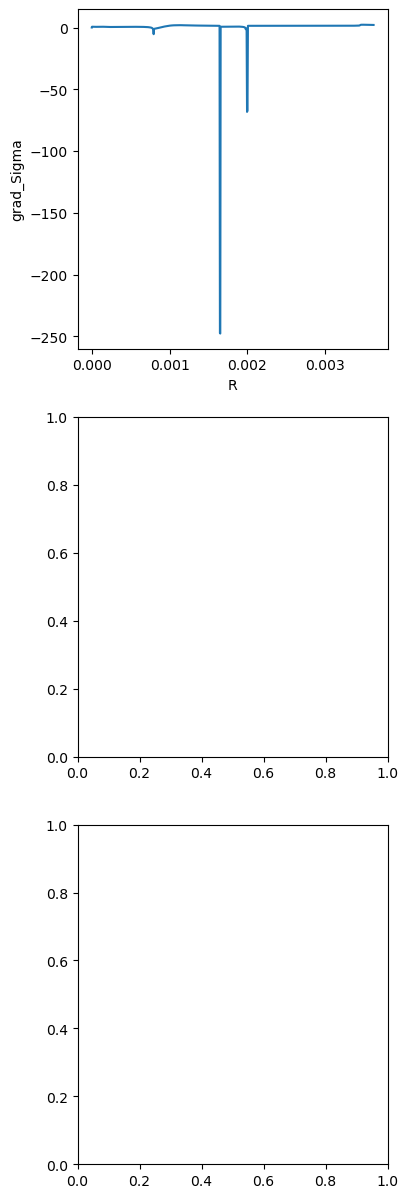

In [16]:
fig, axes = plt.subplots(3,1, figsize=(4,15))
axs = axes.flatten()
sns.lineplot(data=df_ppd, x="R", y="grad_Sigma", ax=axs[0])

## Test 3: Eccentricity Sensitivity

Test torques and damping rates as a function of eccentricity (e = 0.01 to 0.15) for each disk region.

=== Extracting Parameters for Eccentricity Tests ===

Radiation-dom (R=50): p=-1.2349, q=0.3751, h=0.1467
Gas-dom (R=5000): p=1.4940, q=0.6556, h=0.0066
Q=1 Self-reg (R=5e5): p=1.4994, q=0.7474, h=0.0663


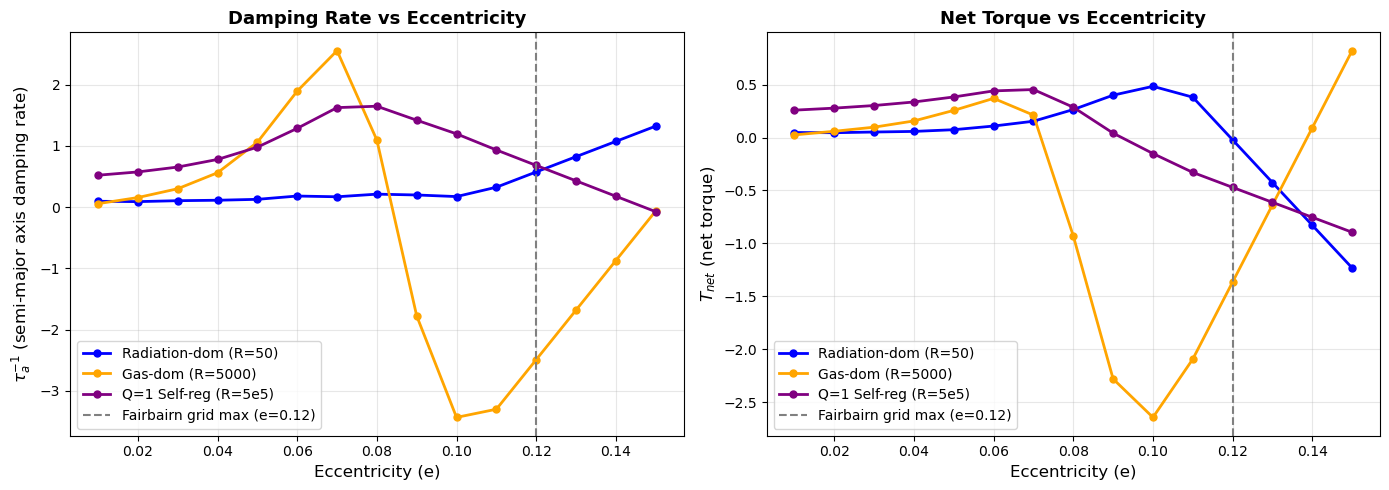


✓ Eccentricity sensitivity tests complete
  Note: e > 0.12 uses extrapolation beyond Fairbairn grid


In [17]:
# Choose representative radii from each region
test_regions = {
    'Radiation-dom (R=50)': 50,
    'Gas-dom (R=5000)': 5000,
    'Q=1 Self-reg (R=5e5)': 5e5
}

# Eccentricity range (0.01 to 0.15, with 15 points)
e_values = np.linspace(0.01, 0.15, 15)

# Store results
ecc_results = {region: {'e': e_values, 'tau_a_inv': [], 'T_net': []} 
               for region in test_regions.keys()}

# Extract parameters and query Fairbairn data
print("=== Extracting Parameters for Eccentricity Tests ===\n")
for region, R in test_regions.items():
    p = powerlaw_p(df, R)
    q = powerlaw_q(df, R)
    h = fairbairn_h(df, R)
    print(f"{region}: p={p:.4f}, q={q:.4f}, h={h:.4f}")
    
    # Query Fairbairn data for each eccentricity
    for e in e_values:
        tau_a_inv = get_tau_a_inv(p, q, h, e)
        T_net = get_T_net(p, q, h, e)
        
        ecc_results[region]['tau_a_inv'].append(tau_a_inv)
        ecc_results[region]['T_net'].append(T_net)

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: tau_a^{-1} vs e
ax = axes[0]
colors = ['blue', 'orange', 'purple']
for (region, data), color in zip(ecc_results.items(), colors):
    ax.plot(data['e'], data['tau_a_inv'], 'o-', color=color, 
            linewidth=2, markersize=5, label=region)

ax.axvline(0.12, color='gray', linestyle='--', linewidth=1.5, 
           label='Fairbairn grid max (e=0.12)')
ax.set_xlabel('Eccentricity (e)', fontsize=12)
ax.set_ylabel(r'$\tau_a^{-1}$ (semi-major axis damping rate)', fontsize=12)
ax.set_title('Damping Rate vs Eccentricity', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=10)

# Panel 2: T_net vs e
ax = axes[1]
for (region, data), color in zip(ecc_results.items(), colors):
    ax.plot(data['e'], data['T_net'], 'o-', color=color, 
            linewidth=2, markersize=5, label=region)

ax.axvline(0.12, color='gray', linestyle='--', linewidth=1.5, 
           label='Fairbairn grid max (e=0.12)')
ax.set_xlabel('Eccentricity (e)', fontsize=12)
ax.set_ylabel(r'$T_{net}$ (net torque)', fontsize=12)
ax.set_title('Net Torque vs Eccentricity', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.show()

print("\n✓ Eccentricity sensitivity tests complete")
print(f"  Note: e > 0.12 uses extrapolation beyond Fairbairn grid")

## Test 4: End-to-End Workflow Verification

Verify the complete data pipeline: disk model → parameter extraction → Fairbairn data cube lookup.

In [18]:
# Test radii (one from each region) 
test_workflow_radii = {
    'Radiation-dominated': 50,
    'Gas-dominated': 5000,
    'Q=1 Self-regulated': 5e5
}

# Fixed eccentricity within Fairbairn grid
test_e = 0.05

# Run end-to-end workflow
workflow_results = []
print("=== End-to-End Workflow Verification ===\n")
print(f"Test eccentricity: e = {test_e}\n")

for region, R in test_workflow_radii.items():
    # Step 1: Extract parameters from disk model
    p = powerlaw_p(df, R)
    q = powerlaw_q(df, R)
    h = fairbairn_h(df, R)
    
    # Determine zone
    zone_idx = np.argmin(np.abs(df['R/Rg'].values - R))
    zone = df.iloc[zone_idx]['zone']
    
    # Step 2: Query Fairbairn data cubes
    tau_a_inv = get_tau_a_inv(p, q, h, test_e)
    T_net = get_T_net(p, q, h, test_e)
    
    workflow_results.append({
        'Region': region,
        'R/Rg': R,
        'Zone': zone,
        'p': f"{p:.4f}",
        'q': f"{q:.4f}",
        'h': f"{h:.4f}",
        'e': test_e,
        'τ_a⁻¹': f"{tau_a_inv:.6f}",
        'T_net': f"{T_net:.6f}"
    })

# Display results table
workflow_df = pd.DataFrame(workflow_results)
print(workflow_df.to_string(index=False))

print("\n✓ End-to-end workflow verification complete")
print("  All interpolations succeeded and returned valid values")
print("\n=== Workflow Summary ===")
print("  1. AGNDisk.spacehub_pretab() → DataFrame with disk properties")
print("  2. powerlaw_p/q, fairbairn_h → Extract (p, q, h) at radius R")
print("  3. get_tau_a_inv, get_T_net → Query Fairbairn data cubes")
print("  ✓ Full pipeline functional")

=== End-to-End Workflow Verification ===

Test eccentricity: e = 0.05

             Region     R/Rg     Zone       p      q      h    e    τ_a⁻¹    T_net
Radiation-dominated     50.0 Standard -1.2349 0.3751 0.1467 0.05 0.126832 0.073642
      Gas-dominated   5000.0 Self-Reg  1.4940 0.6556 0.0066 0.05 1.059677 0.255940
 Q=1 Self-regulated 500000.0 Self-Reg  1.4994 0.7474 0.0663 0.05 0.979124 0.382705

✓ End-to-end workflow verification complete
  All interpolations succeeded and returned valid values

=== Workflow Summary ===
  1. AGNDisk.spacehub_pretab() → DataFrame with disk properties
  2. powerlaw_p/q, fairbairn_h → Extract (p, q, h) at radius R
  3. get_tau_a_inv, get_T_net → Query Fairbairn data cubes
  ✓ Full pipeline functional
